In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import sys
sys.path.insert(0, '../')
from pysheds.grid import Grid
import timeit

%matplotlib inline

In [7]:
grid = Grid.from_raster('../data/dem.tif')
fdir = grid.read_ascii('../data/dir.asc')

# N  NE  E  SE  S  SW  W  NW
dirmap = (64, 128, 1, 2, 4, 8, 16, 32)

In [8]:
gridsize = fdir.size
gridshape = fdir.shape
gridbytes = fdir.nbytes

print(gridshape[0], ' x ', gridshape[1], ' grid')
print(gridsize, ' gridcells')
print(gridbytes / 1000000, 'MB in memory (stored as uint8)')

359  x  367  grid
131753  gridcells
1.054024 MB in memory (stored as uint8)


In [9]:
%timeit acc = grid.accumulation(fdir, dirmap=dirmap)

8.1 ms ± 558 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [10]:
acc = grid.accumulation(fdir, dirmap=dirmap)
pour_y, pour_x = np.unravel_index(np.argmax(acc), gridshape)

In [11]:
%timeit catch = grid.catchment(x=pour_x, y=pour_y, fdir=fdir, dirmap=dirmap, xytype='index')

5.74 ms ± 362 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [26]:
catch = grid.catchment(x=pour_x, y=pour_y, fdir=fdir, dirmap=dirmap, xytype='index')
catchment_cells = np.count_nonzero(catch)
print(f"{catchment_cells} cells in catchment")

76499 cells in catchment


In [ ]:
D_acc = np.logspace(1, 3.7782, 15).astype(int)
times_acc = []

In [28]:
for i in D_acc:
    # Slice a square from the top-left of the flow direction
    fdir_sub = fdir[:i, :i]
    
    # Fresh grid ensures the viewfinder matches fdir_sub exactly
    temp_grid = Grid()
    
    start = timeit.default_timer()
    _ = temp_grid.accumulation(fdir_sub, dirmap=dirmap)
    stop = timeit.default_timer()
    
    times_acc.append(stop - start)
    print(f"Grid {i}x{i} processed in {stop - start:.4f}s")

Grid 10x10 processed in 0.0250s
Grid 15x15 processed in 0.0010s
Grid 24x24 processed in 0.0283s
Grid 39x39 processed in 0.0110s
Grid 62x62 processed in 0.0006s
Grid 98x98 processed in 0.0005s
Grid 155x155 processed in 0.0005s
Grid 244x244 processed in 0.0005s
Grid 386x386 processed in 0.0006s
Grid 610x610 processed in 0.0010s
Grid 964x964 processed in 0.0004s
Grid 1523x1523 processed in 0.0005s
Grid 2406x2406 processed in 0.0005s
Grid 3799x3799 processed in 0.0018s
Grid 6000x6000 processed in 0.0008s


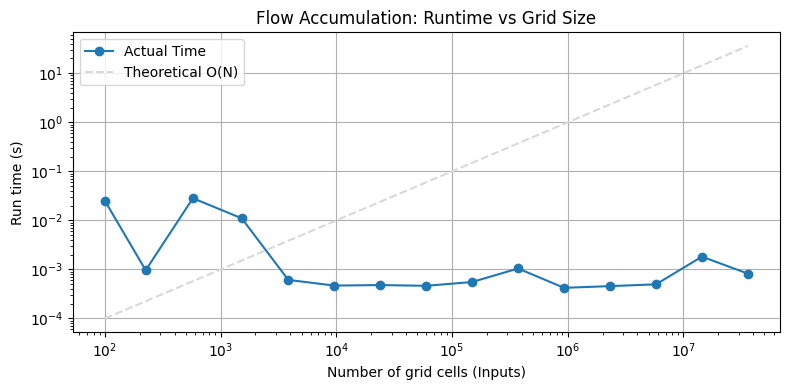

In [30]:
fig, ax = plt.subplots(figsize=(8,4))

ax.loglog(D_acc**2, times_acc, marker='o', label='Actual Time')
ax.loglog(D_acc**2, D_acc**2 / 1e6, linestyle='--', c='0.85', label='Theoretical O(N)')
ax.set_xlabel('Number of grid cells (Inputs)')
ax.set_ylabel('Run time (s)')
ax.set_title('Flow Accumulation: Runtime vs Grid Size')
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()


In [31]:
# 20 steps based on accumulation values
D_catch = np.logspace(2, np.log10(acc.max()), 20).astype(int)
# Find indices where accumulation matches these values
ix_catch = [np.argmin(np.abs(acc.ravel() - i)) for i in D_catch]

times_catch = []
sizes_catch = []

In [32]:
for i in ix_catch:
    p_y, p_x = np.unravel_index(i, fdir.shape)
    
    # Synchronize temp_grid to the full fdir metadata
    temp_grid = Grid()
    temp_grid.viewfinder = fdir.viewfinder
    
    start = timeit.default_timer()
    c_sub = temp_grid.catchment(x=p_x, y=p_y, fdir=fdir, dirmap=dirmap, xytype='index')
    stop = timeit.default_timer()
    
    dt = stop - start
    actual_size = np.count_nonzero(c_sub)
    
    times_catch.append(dt)
    sizes_catch.append(actual_size)
    print(f"Catchment size {actual_size} processed in {dt:.4f}s")

# Convert to arrays for plotting
times_catch = np.asarray(times_catch)
sizes_catch = np.asarray(sizes_catch)

Catchment size 100 processed in 0.0028s
Catchment size 132 processed in 0.0011s
Catchment size 188 processed in 0.0023s
Catchment size 257 processed in 0.0009s
Catchment size 405 processed in 0.0006s
Catchment size 522 processed in 0.0007s
Catchment size 802 processed in 0.0008s
Catchment size 1158 processed in 0.0013s
Catchment size 1630 processed in 0.0013s
Catchment size 2333 processed in 0.0017s
Catchment size 3165 processed in 0.0015s
Catchment size 4608 processed in 0.0021s
Catchment size 6505 processed in 0.0034s
Catchment size 9339 processed in 0.0029s
Catchment size 13235 processed in 0.0024s
Catchment size 19222 processed in 0.0035s
Catchment size 26715 processed in 0.0082s
Catchment size 37003 processed in 0.0043s
Catchment size 50959 processed in 0.0049s
Catchment size 76499 processed in 0.0064s


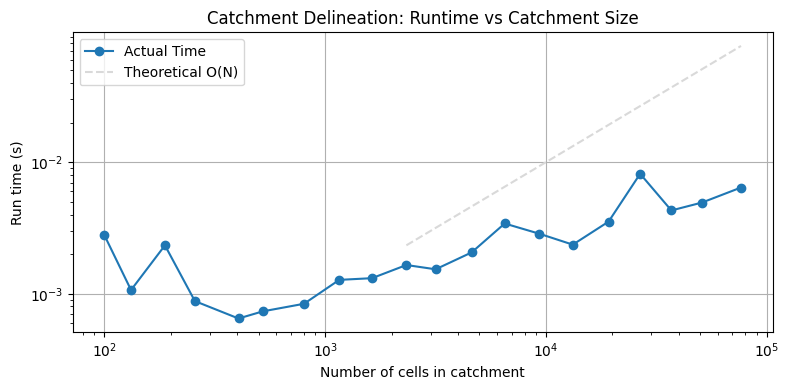

In [33]:
s = pd.Series(times_catch, index=sizes_catch).sort_index()

fig, ax = plt.subplots(figsize=(8,4))

ax.loglog(s.index, s.values, marker='o', label='Actual Time')
ax.loglog(s.index[9:], s.index[9:] / 1e6, linestyle='--', c='0.85', label='Theoretical O(N)')
ax.set_xlabel('Number of cells in catchment')
ax.set_ylabel('Run time (s)')
ax.set_title('Catchment Delineation: Runtime vs Catchment Size')
ax.grid()
ax.legend()
plt.tight_layout()
plt.show()